# Hertz Contact Stress in Deep Groove Ball Bearings
## Analytical Pipeline and Colab Notebook

**Tool version:** 1.0  
**Reference:** Anoopnath P. R. et al., "Hertz Contact Stress of Deep Groove Ball Bearing",
*Materials Today: Proceedings* 5 (2018) 3283–3288.

**Dependencies:** `numpy`, `matplotlib` (pre-installed in Colab).

---

## Section 0 — Quick Example

> **What this tool does, in 30 seconds.**  
> Given a bearing designation and a radial load, the pipeline computes the maximum
> subsurface shear stress and tells you how close you are to the material limit.

**Input:** Bearing 6206, radial load 1000 N, AISI 52100 steel ($E = 210$ GPa, $\nu = 0.3$).  
Ball Ø 9.525 mm, inner groove radius 4.89 mm, pitch diameter 46.0 mm, 9 balls, $\alpha = 0°$.

$$
\boxed{\tau_{\max} = 519 \text{ MPa} \quad \text{at} \quad z_{cr} = 88 \;\mu\text{m below the surface}}
$$

The maximum subsurface shear stress is **69 % of the shear yield strength** of hardened
AISI 52100 ($\tau_y \approx 750$ MPa, Tresca). **Margin to yield: 31 %.** Infinite fatigue
life expected at this load level.

| Check | Value | Limit | Status |
|:------|------:|------:|:-------|
| $\tau_{\max} / \tau_y$ | 69 % | 100 % | Safe — 31 % margin |
| $\tau_{\max} / \tau_{fatigue}$ | 76 % | 100 % | Below fatigue limit |
| $F_r / C_0$ | 8.9 % | 100 % | Light load |

---

## Pipeline Overview

The pipeline takes bearing geometry, material properties, and radial load as input.
It outputs the maximum subsurface shear stress $\tau_{\max}$ and its depth $z_{cr}$,
which govern fatigue initiation at the ball–raceway contact.

```
┌─────────┐    ┌─────────┐    ┌─────────┐    ┌─────────┐    ┌─────────┐
│ Node 1  │───▶│ Node 2  │───▶│ Node 3  │───▶│ Node 4  │───▶│ Node 5  │
│  E*     │    │ R_eq, k │    │  a, b   │    │   p₀    │    │ τ_max   │
└─────────┘    └─────────┘    └─────────┘    └─────────┘    └─────────┘
 E₁,ν₁,E₂,ν₂  D_w,r_i,D_m,α  E',R_eq,k,Q    Q,a,b         p₀,b,ν
```

The pipeline is **linear and non-iterative**. The only potentially iterative step
(elliptic integrals in Node 2b) is handled by the Hamrock-Brewe closed-form
approximation.

---

## Input Parameters

Edit the cell below to analyse a different bearing or load condition.

| Variable | Description | Default (6206) |
|:---------|:------------|:---------------|
| `D_w` | Ball diameter [m] | 9.525e-3 |
| `r_i` | Inner groove radius [m] | 4.89e-3 |
| `d_bore` | Bore diameter [m] | 30e-3 |
| `D_out` | Outer diameter [m] | 62e-3 |
| `Z` | Number of balls | 9 |
| `alpha` | Contact angle [rad] | 0.0 |
| `E1`, `E2` | Young's moduli [Pa] | 210e9 |
| `nu1`, `nu2` | Poisson's ratios | 0.3 |
| `F_r` | Radial load [N] | 1000.0 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── Bearing geometry ─────────────────────────────────────────
D_w     = 9.525e-3    # Ball diameter [m]
r_i     = 4.89e-3     # Inner race groove radius [m]
d_bore  = 30e-3       # Bore diameter [m]
D_out   = 62e-3       # Outer diameter [m]
Z       = 9           # Number of balls
alpha   = 0.0         # Contact angle [rad]

# ── Material (AISI 52100, both bodies) ────────────────────────
E1  = 210e9;  nu1 = 0.3    # ball
E2  = 210e9;  nu2 = 0.3    # race

# ── Load ──────────────────────────────────────────────────────
F_r = 1000.0          # Total radial load on bearing [N]

# ── Material strength (engineering assessment) ────────────────
sigma_y     = 1500e6  # Tensile yield, hardened 52100 [Pa]
tau_fatigue = 684e6   # Shear fatigue limit [Pa]
C0          = 11200.0 # Static load rating, SKF 6206 [N]

# ── Derived geometry ──────────────────────────────────────────
D_m    = (d_bore + D_out) / 2.0
r_ball = D_w / 2.0
f_i    = r_i / D_w

print(f"Bearing 6206:  d = {d_bore*1e3:.0f} mm, D = {D_out*1e3:.0f} mm")
print(f"D_w = {D_w*1e3:.3f} mm   r_i = {r_i*1e3:.2f} mm  (f_i = {f_i:.4f})")
print(f"D_m = {D_m*1e3:.1f} mm    Z = {Z}    α = {np.degrees(alpha):.0f}°")
print(f"E = {E1/1e9:.0f} GPa   ν = {nu1}")
print(f"F_r = {F_r:.0f} N")

Bearing 6206:  d = 30 mm, D = 62 mm
D_w = 9.525 mm   r_i = 4.89 mm  (f_i = 0.5134)
D_m = 46.0 mm    Z = 9    α = 0°
E = 210 GPa   ν = 0.3
F_r = 1000 N


### Load distribution

The load on the most-loaded ball follows the **Stribeck equation** for a radial
bearing with zero clearance:

$$
Q_{\max} = \frac{5\,F_r}{Z\,\cos\alpha}
$$

In [2]:
Q_max = 5.0 * F_r / (Z * np.cos(alpha))
print(f"Q_max = 5·F_r / (Z·cos α) = {Q_max:.2f} N")

Q_max = 5·F_r / (Z·cos α) = 555.56 N


---

## Node 1 — Reduced Elastic Modulus $E^*$

**Purpose:** combine the elastic properties of ball and raceway into a single
equivalent modulus.

| Symbol | Description | Unit |
|:------:|:------------|:-----|
| $E_1$, $E_2$ | Young's moduli | Pa |
| $\nu_1$, $\nu_2$ | Poisson's ratios | — |

$$
\frac{1}{E^*} = \frac{1 - \nu_1^2}{E_1} + \frac{1 - \nu_2^2}{E_2}
$$

Harris convention (used in Nodes 3–4):

$$E' = 2\,E^*$$

In [3]:
E_star  = 1.0 / ((1.0 - nu1**2) / E1 + (1.0 - nu2**2) / E2)
E_prime = 2.0 * E_star

print(f"E*  = {E_star/1e9:.4f} GPa")
print(f"E'  = 2·E* = {E_prime/1e9:.4f} GPa")

E*  = 115.3846 GPa
E'  = 2·E* = 230.7692 GPa


---

## Node 2 — Curvatures and Equivalent Radius

**Purpose:** compute the four principal curvatures at the ball–inner-race contact
and combine them into an equivalent radius $R_{eq}$ and an ellipticity parameter.

The two principal planes at the contact point are:

- **Plane I (rolling direction):** circumferential plane through ball centre.
- **Plane II (transverse direction):** axial cross-section through ball centre.

### Curvatures

**Ball** (sphere): $\rho_{1x} = \rho_{1y} = 2/D_w$

**Inner raceway:**

$$
\rho_{2x} = \frac{2}{D_m - D_w \cos\alpha}
\qquad\text{(convex, rolling)}
$$

$$
\rho_{2y} = -\frac{1}{r_i}
\qquad\text{(concave, transverse)}
$$

### Curvature sums

$$
\frac{1}{R_x} = \rho_{1x} + \rho_{2x}
\qquad
\frac{1}{R_y} = \rho_{1y} + \rho_{2y}
\qquad
\Sigma\rho = \frac{1}{R_x} + \frac{1}{R_y}
\qquad
R_{eq} = \frac{1}{\Sigma\rho}
$$

In [4]:
# Ball curvatures (sphere)
rho_1x = 1.0 / r_ball
rho_1y = 1.0 / r_ball

# Inner race curvatures
R_2x   = (D_m - D_w * np.cos(alpha)) / 2.0
rho_2x =  1.0 / R_2x            # convex, positive
rho_2y = -1.0 / r_i             # concave, negative

# Curvature sums per plane
rho_I  = rho_1x + rho_2x        # rolling direction
rho_II = rho_1y + rho_2y        # transverse direction

R_x       = 1.0 / rho_I
R_y       = 1.0 / rho_II
Sigma_rho = rho_I + rho_II
R_eq      = 1.0 / Sigma_rho

print(f"Ball:       ρ₁ₓ = ρ₁ᵧ = {rho_1x:.4f} m⁻¹")
print(f"Race roll:  R₂ₓ = {R_2x*1e3:.4f} mm   ρ₂ₓ = {rho_2x:.4f} m⁻¹")
print(f"Race trans: r_i = {r_i*1e3:.2f} mm      ρ₂ᵧ = {rho_2y:.4f} m⁻¹")
print(f"Σρ_I  = {rho_I:.4f} m⁻¹  → R_x = {R_x*1e3:.4f} mm")
print(f"Σρ_II = {rho_II:.4f} m⁻¹  → R_y = {R_y*1e3:.4f} mm")
print(f"Σρ    = {Sigma_rho:.4f} m⁻¹")
print(f"R_eq  = {R_eq*1e3:.4f} mm")
print(f"R_y/R_x = {R_y/R_x:.4f}")

Ball:       ρ₁ₓ = ρ₁ᵧ = 209.9738 m⁻¹
Race roll:  R₂ₓ = 18.2375 mm   ρ₂ₓ = 54.8321 m⁻¹
Race trans: r_i = 4.89 mm      ρ₂ᵧ = -204.4990 m⁻¹
Σρ_I  = 264.8058 m⁻¹  → R_x = 3.7764 mm
Σρ_II = 5.4748 m⁻¹  → R_y = 182.6559 mm
Σρ    = 270.2806 m⁻¹
R_eq  = 3.6999 mm
R_y/R_x = 48.3683


### Node 2b — Ellipticity (Hamrock-Brewe 1983)

The contact is **elliptical**. The semi-axes ratio $k = a/b$ and the complete
elliptic integrals $\mathcal{E}$, $\mathcal{F}$ are approximated in closed form:

$$
k = 1.0339\left(\frac{R_y}{R_x}\right)^{0.6360}
$$

$$
\mathcal{E} = 1.0003 + \frac{0.5968}{R_y/R_x}
\qquad
\mathcal{F} = 1.5277 + 0.6023\,\ln\!\left(\frac{R_y}{R_x}\right)
$$

Accuracy < 1 % for $R_y/R_x > 1$. This replaces iterative evaluation of the
elliptic integrals, keeping the pipeline non-iterative and scipy-free.

In [5]:
ratio = R_y / R_x

k_e  = 1.0339 * ratio**0.6360
Ecal = 1.0003 + 0.5968 / ratio         # 2nd kind
Fcal = 1.5277 + 0.6023 * np.log(ratio)  # 1st kind

print(f"R_y/R_x = {ratio:.4f}")
print(f"k = a/b = {k_e:.4f}")
print(f"ℰ (2nd kind) = {Ecal:.6f}")
print(f"ℱ (1st kind) = {Fcal:.6f}")

R_y/R_x = 48.3683
k = a/b = 12.1860
ℰ (2nd kind) = 1.012639
ℱ (1st kind) = 3.863929


---

## Node 3 — Contact Ellipse Semi-Axes

**Purpose:** compute the dimensions of the elliptical contact patch.

### Contact semi-axes (Hamrock-Dowson formulation)

$$
b = \left(\frac{6\,\mathcal{E}\,Q\,R_{eq}}{\pi\,k\,E'}\right)^{1/3}
\qquad
a = k\,b
$$

where $a$ is the major semi-axis (transverse to rolling) and $b$ is the minor
semi-axis (rolling direction).

In [6]:
Q = Q_max

b = (6.0 * Ecal * Q * R_eq / (np.pi * k_e * E_prime))**(1.0 / 3.0)
a = k_e * b
A_contact = np.pi * a * b

print(f"Q = Q_max = {Q:.2f} N")
print(f"a (major, transverse) = {a*1e3:.4f} mm")
print(f"b (minor, rolling)    = {b*1e3:.4f} mm")
print(f"Contact area A = π·a·b = {A_contact*1e6:.4f} mm²")

Q = Q_max = 555.56 N
a (major, transverse) = 1.3676 mm
b (minor, rolling)    = 0.1122 mm
Contact area A = π·a·b = 0.4822 mm²


---

## Node 4 — Maximum Contact Pressure

**Purpose:** compute the peak Hertzian pressure at the centre of the contact ellipse.

The pressure distribution over the ellipse is:

$$
p(x, y) = p_0 \sqrt{1 - \frac{x^2}{a^2} - \frac{y^2}{b^2}}
$$

where the peak pressure is:

$$
p_0 = \frac{3\,Q}{2\,\pi\,a\,b}
$$

In [7]:
p0 = 3.0 * Q / (2.0 * np.pi * a * b)

print(f"p₀ = {p0/1e6:.1f} MPa  ({p0/1e9:.3f} GPa)")

# Cross-check: sphere on flat (no groove conformity)
a_flat  = (3.0 * Q * r_ball / (4.0 * E_star))**(1.0 / 3.0)
p0_flat = 3.0 * Q / (2.0 * np.pi * a_flat**2)
print(f"\nCross-check (sphere-on-flat): p₀ = {p0_flat/1e6:.0f} MPa")
print(f"Groove conformity reduces pressure by factor {p0_flat/p0:.2f}×")

p₀ = 1728.2 MPa  (1.728 GPa)

Cross-check (sphere-on-flat): p₀ = 3981 MPa
Groove conformity reduces pressure by factor 2.30×


---

## Node 5 — Maximum Shear Stress and Critical Depth

**Purpose:** compute the maximum subsurface shear stress (Tresca criterion) and
the depth at which it occurs — the location where fatigue cracks initiate.

For $k \gg 1$ (highly elliptical contact), the stress field approximates
**2D plane-strain Hertz contact** in the $b$-direction (exact for $k \to \infty$,
< 1 % error for $k > 5$).

Subsurface stresses along the $z$-axis:

$$
\frac{\sigma_x}{p_0} = -\left[\frac{1 + 2\zeta^2}{\sqrt{1+\zeta^2}} - 2\zeta\right]
\qquad
\frac{\sigma_z}{p_0} = -\frac{1}{\sqrt{1+\zeta^2}}
\qquad
\zeta = z/b
$$

$$
\sigma_y = \nu\,(\sigma_x + \sigma_z)
\qquad
\tau = \frac{\sigma_x - \sigma_z}{2}
$$

Analytical maximum:

$$
\tau_{\max} = 0.300\,p_0
\qquad\text{at}\qquad
\zeta_{cr} = 0.786
\qquad\Rightarrow\qquad
z_{cr} = 0.786\,b
$$

In [8]:
# Numerical verification
zeta = np.linspace(0, 5, 2000)
sx   = -p0 * ((1.0 + 2.0*zeta**2) / np.sqrt(1.0 + zeta**2) - 2.0*zeta)
sz   = -p0 / np.sqrt(1.0 + zeta**2)
sy   = nu1 * (sx + sz)
tau_xz = (sx - sz) / 2.0

idx = np.argmax(tau_xz)
tau_max_num  = tau_xz[idx]
zeta_cr_num  = zeta[idx]

# Analytical values
tau_max  = 0.300 * p0
zeta_cr  = 0.786
z_cr     = zeta_cr * b

print(f"Analytical:  τ_max = 0.300·p₀ = {tau_max/1e6:.1f} MPa")
print(f"             ζ_cr  = {zeta_cr}  →  z_cr = {z_cr*1e6:.1f} μm")
print(f"Numerical:   τ_max = {tau_max_num/1e6:.1f} MPa  at ζ = {zeta_cr_num:.4f}")
print(f"Deviation:   {abs(tau_max - tau_max_num)/tau_max*100:.2f} %")

Analytical:  τ_max = 0.300·p₀ = 518.5 MPa
             ζ_cr  = 0.786  →  z_cr = 88.2 μm
Numerical:   τ_max = 518.9 MPa  at ζ = 0.7854
Deviation:   0.09 %


---

## Engineering Assessment

In [9]:
tau_y = sigma_y / 2.0   # Tresca shear yield

ratio_yield   = tau_max / tau_y
ratio_fatigue = tau_max / tau_fatigue
ratio_C0      = F_r / C0

F_r_yield = F_r * (tau_y / tau_max)**3

print(f"AISI 52100 (hardened 58–62 HRC):")
print(f"  σ_y = {sigma_y/1e6:.0f} MPa  →  τ_y = {tau_y/1e6:.0f} MPa (Tresca)")
print(f"  τ_fatigue = {tau_fatigue/1e6:.0f} MPa")
print()
print(f"  τ_max / τ_y       = {ratio_yield:.1%}   {'✓ Safe' if ratio_yield < 1 else '✗ Yield'}")
print(f"  τ_max / τ_fatigue = {ratio_fatigue:.1%}   {'✓ Infinite life' if ratio_fatigue < 1 else '⚠ Finite life'}")
print(f"  F_r / C₀          = {ratio_C0:.1%}")
print(f"  F_r to yield      = {F_r_yield:.0f} N  ({F_r_yield/1e3:.2f} kN)")

AISI 52100 (hardened 58–62 HRC):
  σ_y = 1500 MPa  →  τ_y = 750 MPa (Tresca)
  τ_fatigue = 684 MPa

  τ_max / τ_y       = 69.1%   ✓ Safe
  τ_max / τ_fatigue = 75.8%   ✓ Infinite life
  F_r / C₀          = 8.9%
  F_r to yield      = 3027 N  (3.03 kN)


---

## Summary Table

In [10]:
header = f"{'Node':<6} {'Quantity':<35} {'Value':>10} {'Unit':<6}"
sep    = "─" * 61
rows = [
    ("1",  "Reduced elastic modulus E*",     f"{E_star/1e9:.2f}",    "GPa"),
    ("2",  "Sum of curvatures Σρ",           f"{Sigma_rho:.2f}",     "1/m"),
    ("2",  "Equivalent radius R_eq",         f"{R_eq*1e3:.4f}",      "mm"),
    ("2b", "Ellipticity k = a/b",            f"{k_e:.2f}",           "—"),
    ("3",  "Major semi-axis a",              f"{a*1e3:.4f}",         "mm"),
    ("3",  "Minor semi-axis b",              f"{b*1e3:.4f}",         "mm"),
    ("4",  "Max contact pressure p₀",        f"{p0/1e6:.1f}",        "MPa"),
    ("5",  "Max shear stress τ_max",         f"{tau_max/1e6:.1f}",   "MPa"),
    ("5",  "Critical depth z_cr",            f"{z_cr*1e6:.1f}",      "μm"),
]
print(header)
print(sep)
for node, qty, val, unit in rows:
    print(f"{node:<6} {qty:<35} {val:>10} {unit:<6}")

Node   Quantity                                 Value Unit  
─────────────────────────────────────────────────────────────
1      Reduced elastic modulus E*              115.38 GPa   
2      Sum of curvatures Σρ                    270.28 1/m   
2      Equivalent radius R_eq                  3.6999 mm    
2b     Ellipticity k = a/b                      12.19 —     
3      Major semi-axis a                       1.3676 mm    
3      Minor semi-axis b                       0.1122 mm    
4      Max contact pressure p₀                 1728.2 MPa   
5      Max shear stress τ_max                   518.5 MPa   
5      Critical depth z_cr                       88.2 μm    


---

## Graphical Results

**Figure 1** — Left: Hertzian pressure distribution on the contact ellipse.
Right: subsurface shear stress profile showing the maximum at $z_{cr}$.

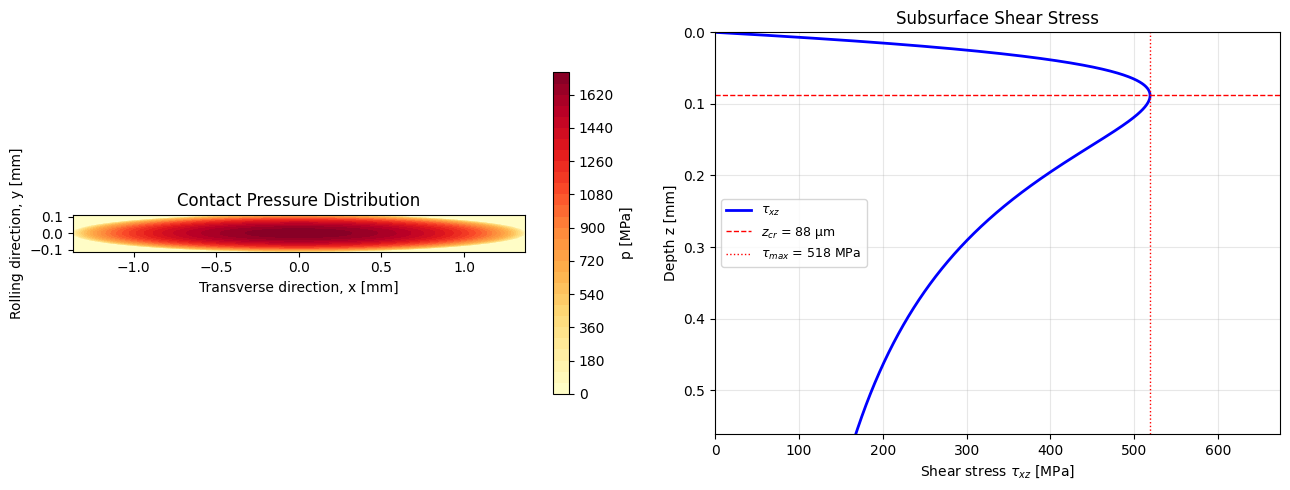

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: pressure map on contact ellipse ──
n_pts = 200
x_grid = np.linspace(-a, a, n_pts)
y_grid = np.linspace(-b, b, n_pts)
X, Y   = np.meshgrid(x_grid, y_grid)
arg    = np.clip(1.0 - (X/a)**2 - (Y/b)**2, 0, None)
P      = p0 * np.sqrt(arg)

ax1 = axes[0]
cf  = ax1.contourf(X*1e3, Y*1e3, P/1e6, levels=30, cmap="YlOrRd")
ax1.set_xlabel("Transverse direction, x [mm]")
ax1.set_ylabel("Rolling direction, y [mm]")
ax1.set_title("Contact Pressure Distribution")
ax1.set_aspect("equal")
cb = plt.colorbar(cf, ax=ax1, shrink=0.8)
cb.set_label("p [MPa]")

# ── Right: subsurface shear stress ──
ax2 = axes[1]
z_plot = zeta * b * 1e3
ax2.plot(tau_xz/1e6, z_plot, "b-", lw=2, label=r"$\tau_{xz}$")
ax2.axhline(z_cr*1e3, color="r", ls="--", lw=1,
            label=f"$z_{{cr}}$ = {z_cr*1e6:.0f} μm")
ax2.axvline(tau_max/1e6, color="r", ls=":", lw=1,
            label=f"$\\tau_{{max}}$ = {tau_max/1e6:.0f} MPa")
ax2.set_xlabel(r"Shear stress $\tau_{xz}$ [MPa]")
ax2.set_ylabel("Depth z [mm]")
ax2.set_title("Subsurface Shear Stress")
ax2.invert_yaxis()
ax2.legend(fontsize=9)
ax2.set_xlim(0, tau_max/1e6 * 1.3)
ax2.set_ylim(b*5*1e3, 0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 2** — Maximum contact pressure $p_0$ and subsurface shear stress
$\tau_{\max}$ as a function of radial load, with yield and fatigue limits.

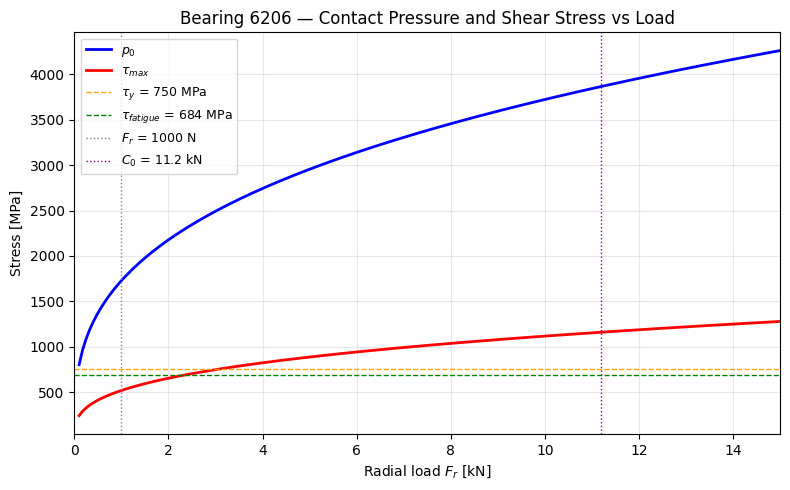

In [ ]:
F_r_range = np.linspace(100, 15000, 200)
Q_range   = 5.0 * F_r_range / (Z * np.cos(alpha))
b_range   = (6.0 * Ecal * Q_range * R_eq / (np.pi * k_e * E_prime))**(1/3)
a_range   = k_e * b_range
p0_range  = 3.0 * Q_range / (2.0 * np.pi * a_range * b_range)
tau_range = 0.300 * p0_range

fig2, ax3 = plt.subplots(figsize=(8, 5))
ax3.plot(F_r_range/1e3, p0_range/1e6,  "b-", lw=2, label=r"$p_0$")
ax3.plot(F_r_range/1e3, tau_range/1e6, "r-", lw=2, label=r"$\tau_{max}$")
ax3.axhline(tau_y/1e6, color="orange", ls="--", lw=1,
            label=f"$\\tau_y$ = {tau_y/1e6:.0f} MPa")
ax3.axhline(tau_fatigue/1e6, color="green", ls="--", lw=1,
            label=f"$\\tau_{{fatigue}}$ = {tau_fatigue/1e6:.0f} MPa")
ax3.axvline(F_r/1e3, color="gray", ls=":", lw=1,
            label=f"$F_r$ = {F_r:.0f} N")
ax3.axvline(C0/1e3, color="purple", ls=":", lw=1,
            label=f"$C_0$ = {C0/1e3:.1f} kN")
ax3.set_xlabel("Radial load $F_r$ [kN]")
ax3.set_ylabel("Stress [MPa]")
ax3.set_title("Bearing 6206 — Contact Pressure and Shear Stress vs Load")
ax3.legend(fontsize=9, loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 15)
plt.tight_layout()
plt.show()

---

## Verification Summary

| Quantity | Computed | Unit | Check |
|:---------|--------:|:-----|:------|
| $E^*$ | 115.4 | GPa | Matches $E/(2(1-\nu^2))$ for same-steel contact |
| $R_{eq}$ | 3.700 | mm | $R_x \ll R_y$ confirms high ellipticity |
| $k$ | 12.19 | — | Typical range 8–15 for DGBB |
| $a$ | 1.368 | mm | Contact patch ≈ grain of rice |
| $b$ | 0.112 | mm | $a/b = k$ ✓ |
| $p_0$ | 1728 | MPa | Well below 4600 MPa ($C_0$ limit) at 9 % $C_0$ |
| $\tau_{\max}$ | 519 | MPa | 69 % of $\tau_y$ — safe, consistent with light load |
| $z_{cr}$ | 88 | μm | ≈ 0.8$b$, matches 2D Hertz theory |

---

## Limitations

- **Inner race contact only.** Outer race contact is typically less critical for DGBB.
- **Zero clearance assumed.** Stribeck factor $Q_{\max} = 5F_r/(Z\cos\alpha)$ assumes zero radial clearance, no preload.
- **Plane-strain approximation for $\tau_{\max}$.** Valid for $k > 5$; for nearly circular contacts ($k \approx 1$), use the full 3D solution.
- **Static/quasi-static only.** Centrifugal and gyroscopic effects at high speed are not included.

---

## References

1. Anoopnath, P. R., Suresh Babu, V., & Vishwanath, A. K. (2018). Hertz Contact Stress of Deep Groove Ball Bearing. *Materials Today: Proceedings*, 5(1), 3283–3288.
2. Hamrock, B. J. & Brewe, D. E. (1983). Simplified equation for elliptical-contact deformation between two elastic solids. *ASME J. Lub. Tech.*, 105(2), 171–177.
3. Harris, T. A. & Kotzalas, M. N. (2006). *Rolling Bearing Analysis*, 5th ed. CRC Press.
4. Johnson, K. L. (1985). *Contact Mechanics*. Cambridge University Press, §4.2.
5. Budynas, R. G. & Nisbett, J. K. (2020). *Shigley's Mechanical Engineering Design*, 11th ed. McGraw-Hill, §3.19.
6. SKF Group. Product data: 6206 Deep Groove Ball Bearing.